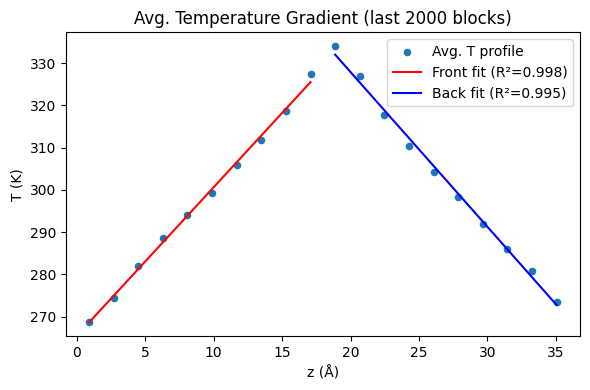

κ = 0.139258 W/mK 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ========== 常量 ==========
kcal_mol_to_j = 6.9477e-21
fs_to_s = 1e-15
A_to_m = 1e-10

# ========== 系统参数 ==========
L = 35.947765  # 盒子长度（Å）
area = L * L * A_to_m * A_to_m  # 横截面积（m²）
timestep = 0.5  # fs
e0 = -444066.94 * kcal_mol_to_j # 体系初始能量

# ========== 温度梯度拟合 ==========
def plot_avg_temp_gradient_split(profile_file, avg_last_n):
    with open(profile_file) as f:
        lines = f.readlines()
    # 找到所有 block 的起始行
    header_idxs = [i for i, line in enumerate(lines) if len(line.strip().split()) == 3]
    n_blocks = len(header_idxs)
    selected_idxs = header_idxs[-avg_last_n:]  # 最后 avg_last_n 个 block
    # 读取所有温度（每个 block 的上半 + 下半 bin 温度）
    all_temps = []
    for idx in selected_idxs:
        n_chunks = int(lines[idx].strip().split()[1])
        upper = lines[idx+1 : idx+1 + n_chunks//2]
        lower = lines[idx+1 + n_chunks//2 : idx+1 + n_chunks]
        current_temps = []
        current_zs = []
        for line in upper + lower:
            parts = line.strip().split()
            if len(parts) != 4:
                continue
            _, z, _, temp = parts
            z = float(z) * L
            temp = float(temp)
            current_zs.append(z)
            current_temps.append(temp)
        all_temps.append(current_temps)
    all_temps = np.array(all_temps)  # shape: (n_blocks, n_bins)
    mean_temps = np.mean(all_temps, axis=0)  # shape: (n_bins,)
    mean_zs = np.array(current_zs)
    mean_temps_K = mean_temps
    # 按照 z 方向分为前半段和后半段
    n = len(mean_zs)
    mid = n // 2
    zs1, temps1 = mean_zs[:mid], mean_temps_K[:mid]
    zs2, temps2 = mean_zs[mid:], mean_temps_K[mid:]
    # 拟合前半段
    reg1 = LinearRegression().fit(zs1.reshape(-1, 1), temps1.reshape(-1, 1))
    fit1 = reg1.predict(zs1.reshape(-1, 1))
    r2_1 = reg1.score(zs1.reshape(-1, 1), temps1.reshape(-1, 1))
    grad1 = np.polyfit(zs1, temps1, 1)[0]
    # 拟合后半段
    reg2 = LinearRegression().fit(zs2.reshape(-1, 1), temps2.reshape(-1, 1))
    fit2 = reg2.predict(zs2.reshape(-1, 1))
    r2_2 = reg2.score(zs2.reshape(-1, 1), temps2.reshape(-1, 1))
    grad2 = -np.polyfit(zs2, temps2, 1)[0]
    # 绘图
    plt.figure(figsize=(6, 4))
    plt.scatter(mean_zs, mean_temps_K, label="Avg. T profile", s=20)
    plt.plot(zs1, fit1, color='red', label=f'Front fit (R²={r2_1:.3f})')
    plt.plot(zs2, fit2, color='blue', label=f'Back fit (R²={r2_2:.3f})')
    plt.xlabel('z (Å)')
    plt.ylabel('T (K)')
    plt.title(f'Avg. Temperature Gradient (last {avg_last_n} blocks)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return (grad1 + grad2) / 2 / A_to_m

# ========== 从 data 文件读取所有时间点的热流 ==========
def read_all_heat_flux(data_file):
    dq_list = []
    etotal_list = []
    time_list = []
    with open(data_file) as f:
        for line in f:
            parts = line.strip().split()
            step = int(parts[0])
            temp = float(parts[1])
            dq = float(parts[4]) * kcal_mol_to_j  # 热流
            etotal = float(parts[3]) * kcal_mol_to_j  # 总能量
            time = step * timestep * fs_to_s
            dq_list.append(dq)
            etotal_list.append(etotal)
            time_list.append(time)
    # 做能量修正
    dq_corr = [dq - (etotal - e0) for dq, etotal in zip(dq_list, etotal_list)]
    return dq_corr, time_list

# ========== 主函数 ==========
def main(data_file, profile_file, n):
    dq_list, time_list = read_all_heat_flux(data_file)
    gradient = plot_avg_temp_gradient_split(profile_file, n)
    kappa = np.mean(dq_list[-1] - dq_list[-n]) / ((area * (time_list[-1] - time_list[-n])) * gradient)
    print(f"κ = {kappa:.6f} W/mK ")

# ========== 调用入口 ==========
data_file = 'data.txt' #data.txt收录了第一步后的MD数据，由log文件整理而来，以便分析
profile_file = 'profile.mp'
n = 2000
main(data_file, profile_file, n)